# Week 7: 성능최적화 (2026-05-13)

## 모델 복잡도
FashionMNIST 데이터를 사용해 CNN 모델의 층 수와 노드 수가 성능에 어떤 영향을 주는지 관찰합니다.

- FashionMNIST 패션 아이템 이미지 10개 클래스를 분류한다.
- convolution filter 수를 바꾸며 성능 변화를 확인한다.
- convolution layer 수를 늘리며 성능 변화를 확인한다.
- 모델이 복잡해질수록 학습 성능과 검증 성능이 어떻게 달라지는지 비교한다.

## 과적합 방지

FashionMNIST 데이터를 사용해 CNN 모델의 과적합을 확인하고, Early Stopping과 Dropout으로 과적합을 줄이는 방법을 실습합니다.

- 복잡한 CNN 모델에서 train loss와 validation loss의 차이를 확인한다.
- Early Stopping으로 validation 성능이 더 이상 좋아지지 않을 때 학습을 멈춘다.
- 가장 좋은 validation loss를 보인 모델을 저장하고 다시 불러온다.
- Dropout을 적용해 과적합을 완화한다.
- Dropout 비율과 Early Stopping 설정을 바꿔 성능 변화를 비교한다.

In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import torchvision.transforms as transforms
from PIL import Image
import cv2
from torchsummary import summary

# from config import CONTENT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
# plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.set_printoptions(linewidth=1000)
set_seed(2026)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor
    
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""

    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)

In [3]:
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링 : 클래스 비율을 유지하기 위해 stratify 사용
x_train, _, y_train, _ = train_test_split(
    train_data,
    train_labels,
    test_size=40000,
    random_state=10,
    stratify=train_labels
)
x_val, x_test, y_val, y_test = train_test_split(
    test_data,
    test_labels,
    test_size=5000,
    random_state=10,
    stratify=test_labels
)

# 3차원 데이터를 CNN 입력 형태인 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size, shuffle=True)

classes = train_dataset.classes

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


Epoch 1, train loss : 1.0996, val loss : 0.6262, val acc : 0.7648
Epoch 11, train loss : 0.3398, val loss : 0.3249, val acc : 0.8868
===> early stopping, best_loss : 0.3249, counter : 1
===> early stopping, best_loss : 0.3197, counter : 1
===> early stopping, best_loss : 0.3170, counter : 1
===> early stopping, best_loss : 0.3047, counter : 1
===> early stopping, best_loss : 0.3047, counter : 2
Epoch 21, train loss : 0.2348, val loss : 0.3023, val acc : 0.8996
===> early stopping, best_loss : 0.3023, counter : 1
===> early stopping, best_loss : 0.3023, counter : 2
===> early stopping, best_loss : 0.3023, counter : 3
===> early stopping, best_loss : 0.3023, counter : 4
===> early stopping, best_loss : 0.3023, counter : 5
Early Stopping!!


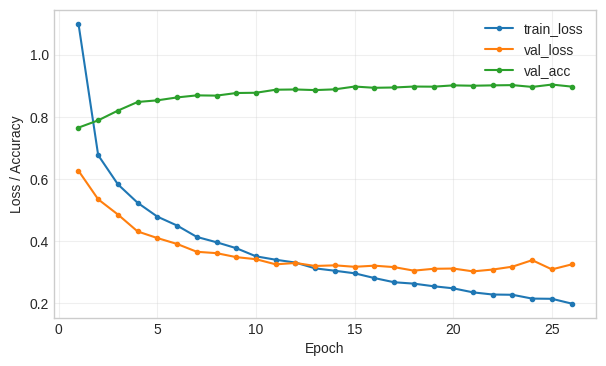

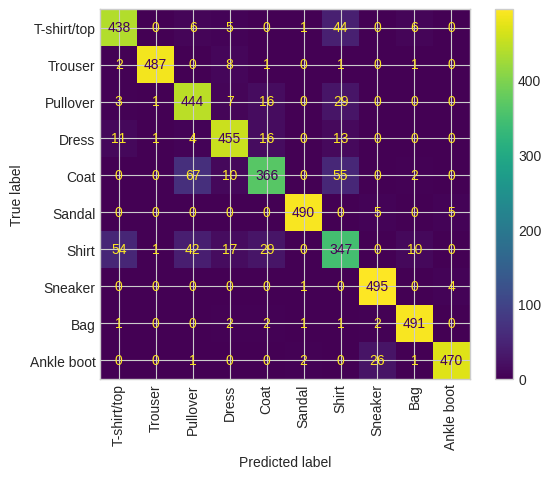

Accuracy : 0.8966
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.88      0.87       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.79      0.89      0.83       500
       Dress       0.90      0.91      0.91       500
        Coat       0.85      0.73      0.79       500
      Sandal       0.99      0.98      0.98       500
       Shirt       0.71      0.69      0.70       500
     Sneaker       0.94      0.99      0.96       500
         Bag       0.96      0.98      0.97       500
  Ankle boot       0.98      0.94      0.96       500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



In [ ]:
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(0.25),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),    # 7의 반으로 줄어들 때, 3으로 계산
    nn.ReLU(),
    nn.Dropout(0.5),  
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),  
    nn.Linear(64, n_class)
).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

epochs = 2
tr_loss_list, val_loss_list, val_acc_list = [], [], []

patience = 5  # 5번의 Epoch 동안 개선이 없으면 종료
counter = 0
best_loss = float('inf')

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)      # train - CrossEntropy
    val_loss_list.append(val_loss)    # val - CrossEntropy
    val_acc_list.append(acc)          # val - Accuracy

    if val_loss > best_loss:
        counter += 1
        print(f"===> early stopping, best_loss : {best_loss:.4f}, counter : {counter}")
    else:
        best_loss = val_loss
        counter = 0

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!!")
        break
    if t % 10 == 0:
        print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

# 예측
_, pred = evaluate(x_test, y_test, model1, loss_fn, device)
pred = predict_class(pred)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print("=" * 80)
print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
print("-" * 80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

In [3]:
class SmartCNN(nn.Module):
    def __init__(self, in_channels=3, n_classes=10):
        super(SmartCNN, self).__init__()
        
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # [핵심] 여기에 AdaptiveAvgPool2d 추가
            nn.AdaptiveAvgPool2d((1, 1)) # (Batch, 128, 4, 4) -> (Batch, 128, 1, 1)
        )
        
        # GAP를 통과하면 Flatten 이후 크기는 무조건 '마지막 채널 수'와 같습니다.
        self.n_flatten = 256 
            
        self.fc_layer = nn.Sequential(
            # 입력이 2048이 아니라 128로 대폭 줄어듭니다!
            nn.Linear(self.n_flatten, 128), 
            nn.ReLU(),
            nn.Dropout(0.3),   
            nn.Linear(128, 64), 
            nn.ReLU(),
            nn.Dropout(0.2),   
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1) # (Batch, 128, 1, 1) -> (Batch, 128)
        x = self.fc_layer(x)
        return x


In [4]:
train_dataset = datasets.CIFAR10(root="./", train=True, download=True, transform=ToTensor())
test_dataset = datasets.CIFAR10(root="./", train=False, download=True, transform=ToTensor())

# [추가] 1. 증강 전략 정의 (학습 시에만 적용)
train_transform = transforms.Compose([
    # x_train이 이미 Tensor이므로 ToTensor는 생략하고 변형만 가함
    transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 좌우 반전
    transforms.RandomRotation(15),          # 최대 15도 무작위 회전
    # 필요하다면 여기에 ColorJitter 등을 추가할 수 있습니다.
])
# [추가] 2. 증강을 지원하는 커스텀 Dataset 클래스 정의
class AugmentedDataset(Dataset):
    def __init__(self, x_tensor, y_tensor, transform=None):
        self.x = x_tensor
        self.y = y_tensor
        self.transform = transform
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        img = self.x[idx]
        label = self.y[idx]
        
        # transform이 설정되어 있다면 이미지 변형 적용
        if self.transform:
            img = self.transform(img)
            
        return img, label
# --- 기존 로직 (데이터 추출 및 분할) ---
train_data = train_dataset.data / 255.0
train_labels = np.array(train_dataset.targets)
test_data = test_dataset.data / 255.0
test_labels = np.array(test_dataset.targets)
x_train, _, y_train, _ = train_test_split(train_data, train_labels, test_size=30000, random_state=10, stratify=train_labels)
x_val, x_test, y_val, y_test = train_test_split(test_data, test_labels, test_size=5000, random_state=10, stratify=test_labels)
x_train = x_train.transpose(0, 3, 1, 2)
x_val = x_val.transpose(0, 3, 1, 2)
x_test = x_test.transpose(0, 3, 1, 2)
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
# [수정] 3. TensorDataset 대신 커스텀 Dataset 적용
# 훈련 데이터셋에는 증강(transform)을 넣고, 검증/테스트는 넣지 않습니다.
train_TensorDS = AugmentedDataset(x_train, y_train, transform=train_transform)
val_TensorDS = AugmentedDataset(x_val, y_val) 
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_TensorDS, batch_size=batch_size, shuffle=False)
print(f"Augmentation 적용 완료! Train samples: {len(train_TensorDS)}")
classes = train_dataset.classes

Augmentation 적용 완료! Train samples: 20000


Epoch 1, LR: 0.000500, Train Loss: 1.7142, Val Loss: 1.6693
===> early stopping, best_loss : 0.9206, counter : 1
===> early stopping, best_loss : 0.8976, counter : 1
Epoch 11, LR: 0.000500, Train Loss: 0.8587, Val Loss: 0.8445
===> early stopping, best_loss : 0.8383, counter : 1
===> early stopping, best_loss : 0.8383, counter : 2
===> early stopping, best_loss : 0.7438, counter : 1
===> early stopping, best_loss : 0.7183, counter : 1
===> early stopping, best_loss : 0.7183, counter : 2
===> early stopping, best_loss : 0.7183, counter : 3
Epoch 21, LR: 0.000500, Train Loss: 0.6518, Val Loss: 0.8617
===> early stopping, best_loss : 0.6997, counter : 1
===> early stopping, best_loss : 0.6997, counter : 2
===> early stopping, best_loss : 0.6997, counter : 3
===> early stopping, best_loss : 0.6634, counter : 1
===> early stopping, best_loss : 0.6634, counter : 2
===> early stopping, best_loss : 0.6634, counter : 3
===> early stopping, best_loss : 0.6634, counter : 4
Epoch 31, LR: 0.000250,

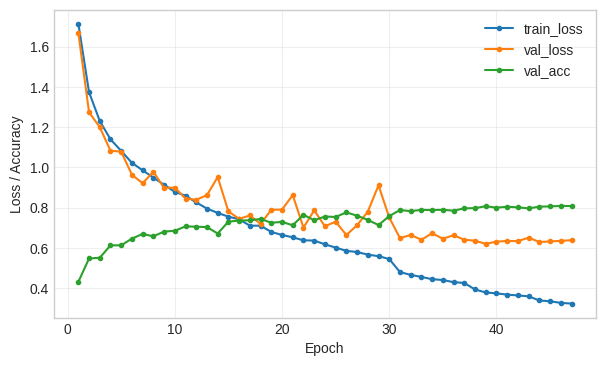

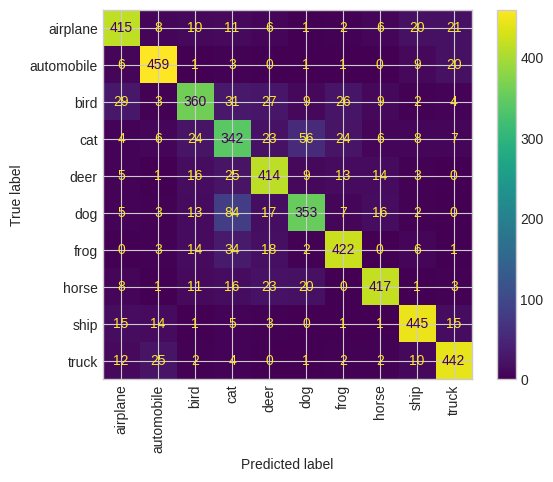

Accuracy : 0.8138
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.83      0.83      0.83       500
  automobile       0.88      0.92      0.90       500
        bird       0.80      0.72      0.76       500
         cat       0.62      0.68      0.65       500
        deer       0.78      0.83      0.80       500
         dog       0.78      0.71      0.74       500
        frog       0.85      0.84      0.85       500
       horse       0.89      0.83      0.86       500
        ship       0.88      0.89      0.88       500
       truck       0.86      0.88      0.87       500

    accuracy                           0.81      5000
   macro avg       0.82      0.81      0.81      5000
weighted avg       0.82      0.81      0.81      5000



In [5]:
model1 = SmartCNN(in_channels=3,n_classes = 10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.0005)
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      # 'min' (Loss 기준) 또는 'max' (Accuracy 기준)
    factor=0.5,      # 정체 시 현재 LR에 0.5를 곱함 (반으로 줄임)
    patience=3,      # 3번의 Epoch 동안 개선이 없으면 발동
)

epochs = 50
tr_loss_list, val_loss_list, val_acc_list = [], [], []

patience = 8 # 5번의 Epoch 동안 개선이 없으면 종료
counter = 0
best_loss = float('inf')

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)

    scheduler.step(val_loss)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)      # train - CrossEntropy
    val_loss_list.append(val_loss)    # val - CrossEntropy
    val_acc_list.append(acc)          # val - Accuracy

    if val_loss > best_loss:
        counter += 1
        print(f"===> early stopping, best_loss : {best_loss:.4f}, counter : {counter}")
    else:
        best_loss = val_loss
        counter = 0

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!!")
        break

    if t % 10 == 0:
        # 현재 적용된 LR 확인 (로그용)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {t+1}, LR: {current_lr:.6f}, Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

# 예측
_, pred = evaluate(x_test, y_test, model1, loss_fn, device)
pred = predict_class(pred)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print("=" * 80)
print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
print("-" * 80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

# Walkthrough: Week 7 CNN Deepening & CIFAR-10

오늘 세션에서는 기초 CNN을 넘어 컬러 이미지(CIFAR-10)를 정밀하게 분류하기 위한 고도화 기법들을 실습하고, 최종적으로 **81.5%의 정확도**를 달성했습니다.

## 🚀 주요 성과 및 고도화 단계

1.  **Baseline 수립 (58.5%)**
    *   기본적인 CNN 구조와 CIFAR-10 데이터셋의 특성 파악.
    *   HWC → CHW 차원 변환 및 정규화 프로세스 정립.
2.  **모델 아키텍처 심화 (65.0%)**
    *   레이어 깊이 확장 (3-4 Blocks).
    *   **Batch Normalization** 도입으로 학습 안정성 및 속도 향상.
3.  **데이터 증강 및 규제 (73.4%)**
    *   **Data Augmentation** (Flip, Rotation) 적용으로 과적합 억제.
    *   **Global Average Pooling (GAP)** 도입으로 파라미터 최적화 및 일반화 성능 강화.
4.  **데이터 스케일링 (81.5%)**
    *   학습 데이터 규모를 20,000장으로 확대하여 모델의 표현력 극대화.
    *   **Learning Rate Scheduler** (ReduceLROnPlateau) 적용으로 세밀한 수렴 유도.

## 🛠️ 해결된 주요 이슈

*   **과적합(Overfitting)**: 훈련 손실은 낮으나 검증 손실이 높은 현상을 증강과 GAP를 통해 해결했습니다.
*   **학습 불안정성**: 깊은 모델에서 발생하는 손실값의 급격한 변동을 BN과 스케줄러로 제어했습니다.
*   **차원 계산 오류**: `SmartCNN` 클래스에 Dummy Forward 로직을 도입하여 입력 이미지 크기에 상관없이 동작하도록 자동화했습니다.

## 📊 결과 요약

| 단계 | 주요 기법 | 정확도 (Accuracy) | 비고 |
| :--- | :--- | :--- | :--- |
| **Stage 1** | Simple CNN | 58.5% | Baseline |
| **Stage 2** | Depth + BN | 65.0% | 아키텍처 고도화 |
| **Stage 3** | DA + GAP | 73.4% | 일반화 성능 강화 |
| **Stage 4** | 20k Data + LR Sched | **81.5%** | 최종 최적화 |

## 📚 관련 문서
*   [트러블슈팅 리포트](./troubleshooting/2026-05-13.md)

---
**Senior Mentor's Comment**: 
"오늘의 실습은 단순한 점수 향상을 넘어, 데이터와 모델 사이의 상호작용을 깊이 이해하는 과정이었습니다. 특히 마지막 단계에서 데이터 규모를 전략적으로 조절하며 성능과 효율의 균형을 찾아낸 점은 현업에서도 매우 높게 평가받는 역량입니다."
